/tmp/ipykernel_29867/3683667183.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("MSFT", start="2013-08-01", end="2023-08-01")
[*********************100%***********************]  1 of 1 completed


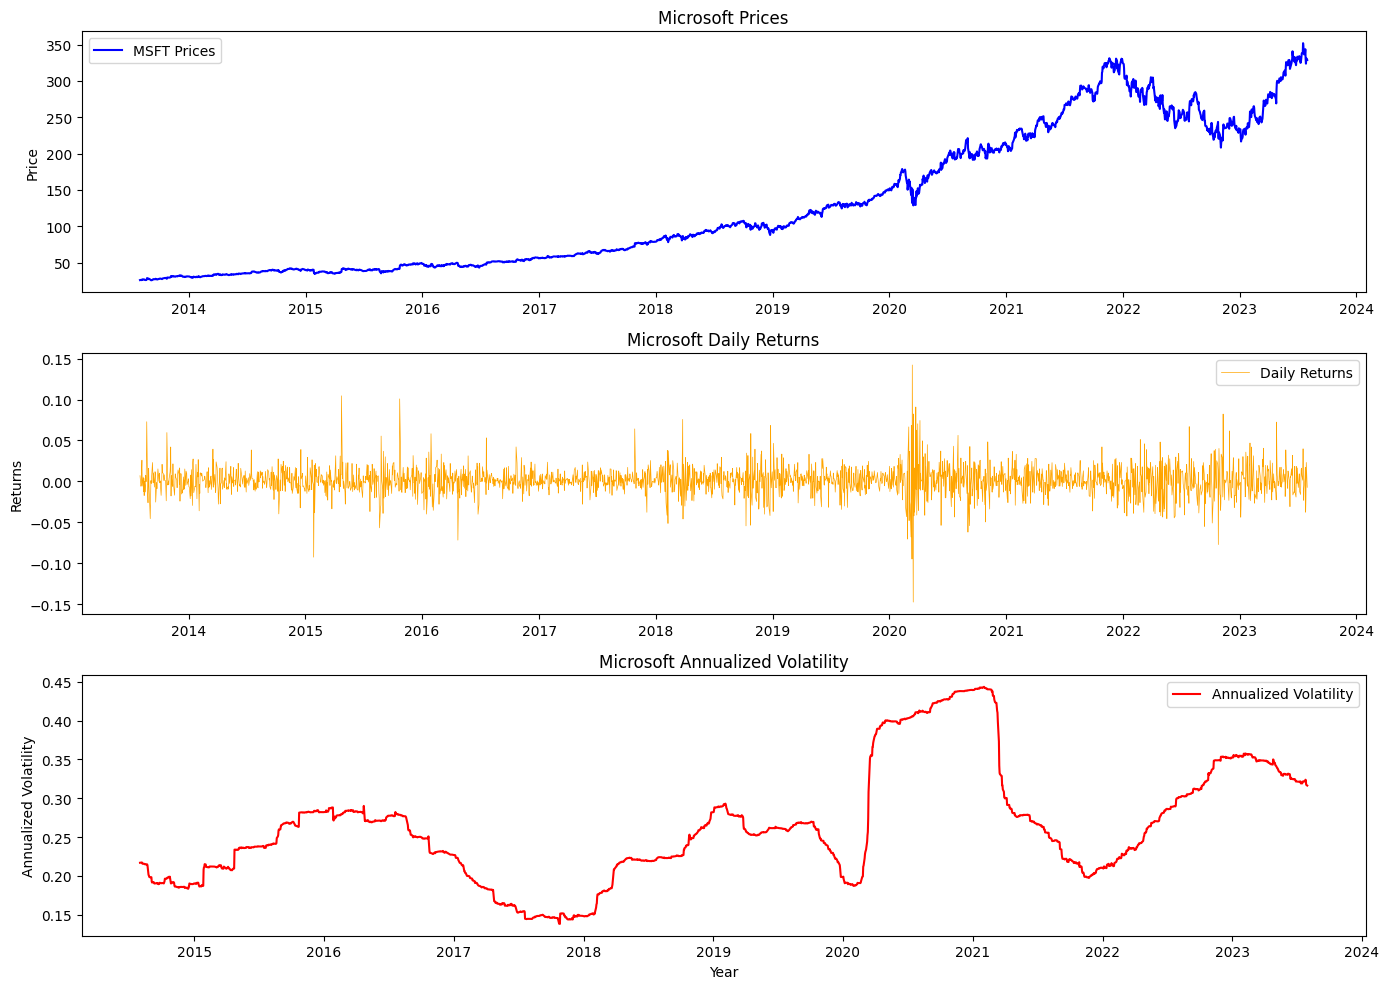

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Fetch MSFT data from Yahoo Finance for 10 years
df = yf.download("MSFT", start="2013-08-01", end="2023-08-01")

# Fix for latest yfinance MultiIndex
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Calculate daily returns and annualized volatility
df['Returns'] = df['Close'].pct_change()
df['Volatility'] = df['Returns'].rolling(window=252).std() * np.sqrt(252)

# Plot the Microsoft prices
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(df.index, df['Close'], label='MSFT Prices', color='blue')
plt.title('Microsoft Prices')
plt.ylabel('Price')
plt.legend()

# Plot the daily returns
plt.subplot(3, 1, 2)
plt.plot(df.index, df['Returns'], label='Daily Returns', color='orange', lw=0.5)
plt.title('Microsoft Daily Returns')
plt.ylabel('Returns')
plt.legend()

# Plot the annualized volatility
plt.subplot(3, 1, 3)
plt.plot(df.index, df['Volatility'], label='Annualized Volatility', color='red')
plt.title('Microsoft Annualized Volatility')
plt.ylabel('Annualized Volatility')
plt.xlabel('Year')
plt.legend()

plt.tight_layout()
plt.show()